In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [133]:
df = pd.read_csv('final_diabetes_dataset.csv')
dup = df.copy()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,6.0,148.0,72.0,35.0,125.0,NaN,0.627,50.0,1.0,Obese,Pre-Senior,Diabetes
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,NaN,0.0,Overweight,Adult,Normal
2,NaN,183.0,NaN,29.0,125.0,23.3,NaN,32.0,1.0,Normal,Missing,Diabetes
3,NaN,89.0,66.0,23.0,NaN,28.1,0.167,21.0,0.0,Overweight,Young,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,Obese,Adult,Prediabetes


In [134]:
for column in df.columns:
    print(column,': ',df[column].unique())

Pregnancies :  [ 6.  1. nan  0.  5.  3. 10.  2.  8.  4.  7.  9. 11. 13. 15. 17. 12. 14.]
Glucose :  [148.  85. 183.  89. 137. 116.  78. 115. 197. 125. 110. 168. 139. 189.
 166. 100. 118. 107. 103. 126.  99. 196. 119. 143. 147.  97. 145. 117.
 109. 158.  88.  92. 122. 138. 102.  nan 111. 180. 133. 106. 171. 159.
 146.  71. 105. 101. 176. 150.  73. 187.  84.  44. 141. 114.  95. 129.
  62. 131. 112. 113.  74.  83. 136.  80. 123. 134. 142. 144.  93. 151.
  96. 155. 160. 124. 132. 120. 173. 170. 128. 108.  90. 156. 153. 188.
 152. 104.  87.  79.  75. 179. 130. 194. 181. 135. 162. 184.  81. 140.
 177. 164.  91. 165.  86. 193. 191. 161.  77. 182. 157. 178.  61. 127.
  82.  72. 172.  94. 175. 195. 154.  76.  68.  57. 186. 198. 121.  98.
  67. 174. 167. 199.  56. 169. 149.  65. 190.]
BloodPressure :  [ 72.  66.  nan  40.  74.  50.  70.  96.  92.  60.  84.  88.  90.  80.
  94.  76.  82.  75.  58.  78.  68.  64. 110.  56.  62.  85.  86.  44.
  65. 108.  55.  48. 122.  54.  30.  52.  98. 104. 102.

In [135]:
df.dropna(subset=['Outcome'], inplace=True)

In [136]:
df = df.replace('missing',np.nan)
df = df.replace('Missing',np.nan)
df.replace(0, np.nan, inplace=True)
df['Outcome'] = dup['Outcome']


In [137]:
df.shape

(691, 12)

In [138]:
df.duplicated().sum()

np.int64(0)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               521 non-null    float64
 1   Glucose                   620 non-null    float64
 2   BloodPressure             621 non-null    float64
 3   SkinThickness             624 non-null    float64
 4   Insulin                   623 non-null    float64
 5   BMI                       621 non-null    float64
 6   DiabetesPedigreeFunction  623 non-null    float64
 7   Age                       629 non-null    float64
 8   Outcome                   691 non-null    float64
 9   BMI_Category              622 non-null    object 
 10  Age_Group                 627 non-null    object 
 11  Glucose_Level             618 non-null    object 
dtypes: float64(9), object(3)
memory usage: 70.2+ KB


In [140]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,521.000000,620.000000,621.000000,624.000000,623.000000,621.00000,623.000000,629.000000,691.000000
mean,4.610365,121.837097,72.748792,29.008013,139.582665,32.50789,0.475669,33.445151,0.347323
std,3.343163,30.832932,11.782492,8.685790,84.881471,6.86090,0.341025,11.873897,0.476464
min,1.000000,44.000000,30.000000,7.000000,15.000000,18.20000,0.078000,21.000000,0.000000
25%,2.000000,100.000000,65.000000,25.000000,123.500000,27.60000,0.241000,24.000000,0.000000
50%,4.000000,117.000000,72.000000,29.000000,125.000000,32.30000,0.383000,29.000000,0.000000
75%,7.000000,140.000000,80.000000,32.000000,125.000000,36.50000,0.612500,41.000000,1.000000
max,17.000000,199.000000,110.000000,99.000000,846.000000,67.10000,2.420000,81.000000,1.000000


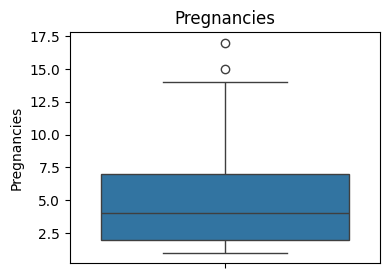

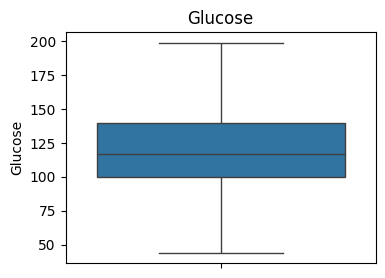

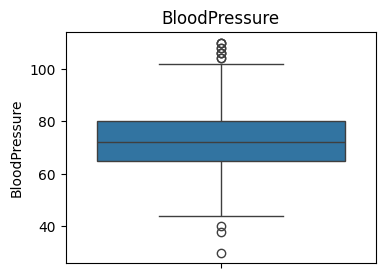

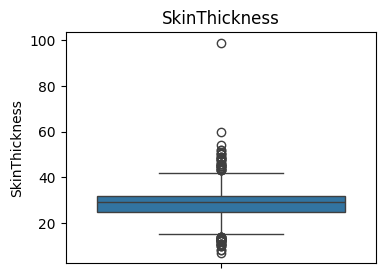

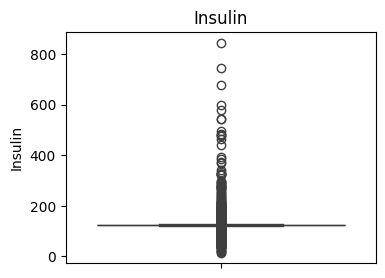

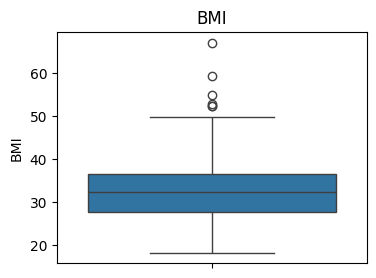

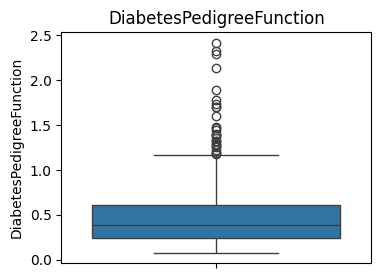

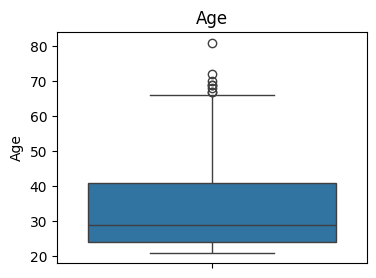

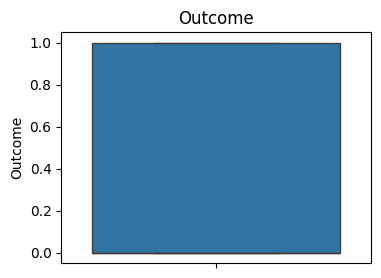

In [141]:
for col in df.columns:
    if df[col].dtype != 'object':
        plt.figure(figsize=(4,3))
        sns.boxplot(df[col].dropna())
        plt.title(col)
        plt.show()

In [142]:
#Outlier Capping (Winsorization)
num_cols_for_cap = ['Pregnancies', 'Glucose', 'BloodPressure',
                    'SkinThickness', 'Insulin', 'BMI',
                    'DiabetesPedigreeFunction', 'Age']

for col in num_cols_for_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping done.")


Outlier capping done.


In [143]:
for col in df.columns:
    if df[col].dtype != 'object':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(col, ":", len(outliers))

#insulin hass outlier -_-

Pregnancies : 0
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0
DiabetesPedigreeFunction : 0
Age : 0
Outcome : 0


In [144]:
# missing vals ,this is  innneficient code idc
df['Pregnancies'] = df['Pregnancies'].fillna(df['Pregnancies'].median())

In [145]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].median())

In [146]:
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())

In [147]:
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())

In [148]:
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())

In [149]:
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

In [150]:
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].fillna(df['DiabetesPedigreeFunction'].median())

In [151]:
df['Age_Group'] = df['Age_Group'].fillna(df['Age_Group'].mode()[0])


In [152]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [153]:
df['BMI_Category'] = df['BMI_Category'].fillna(df['BMI_Category'].mode()[0])


In [154]:
df['Glucose_Level'] = df['Glucose_Level'].fillna(df['Glucose_Level'].mode()[0])

In [155]:
cat_cols = ['BMI_Category', 'Age_Group', 'Glucose_Level', 'Outcome']

for col in cat_cols:
    print()
    print(col,': ')

    print(df[col].value_counts(dropna=False))



BMI_Category : 
BMI_Category
Obese          455
Overweight     149
Normal          84
Underweight      3
Name: count, dtype: int64

Age_Group : 
Age_Group
Young         391
Adult         134
Mid            97
Pre-Senior     46
Senior         23
Name: count, dtype: int64

Glucose_Level : 
Glucose_Level
Prediabetes    374
Normal         164
Diabetes       153
Name: count, dtype: int64

Outcome : 
Outcome
0.0    451
1.0    240
Name: count, dtype: int64


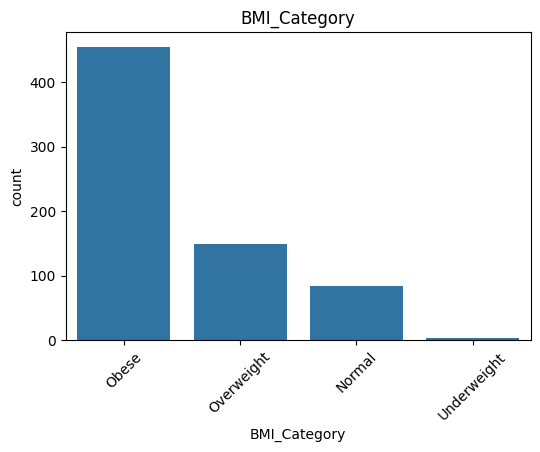

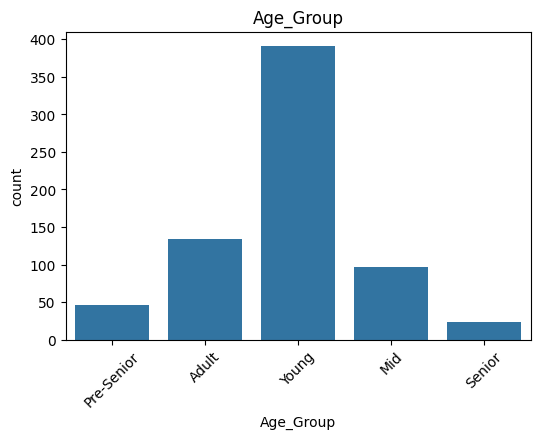

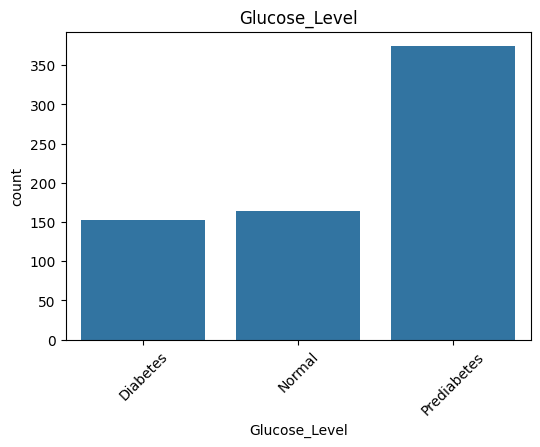

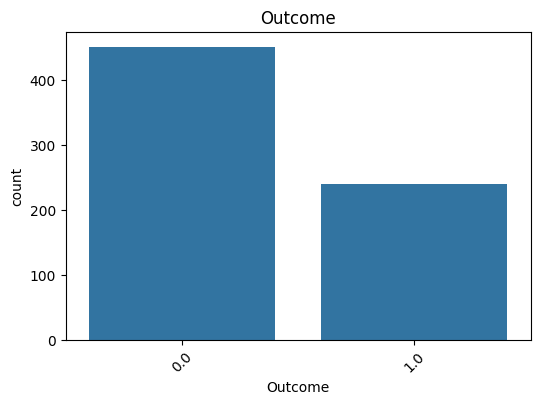

In [156]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               691 non-null    float64
 1   Glucose                   691 non-null    float64
 2   BloodPressure             691 non-null    float64
 3   SkinThickness             691 non-null    float64
 4   Insulin                   691 non-null    float64
 5   BMI                       691 non-null    float64
 6   DiabetesPedigreeFunction  691 non-null    float64
 7   Age                       691 non-null    float64
 8   Outcome                   691 non-null    float64
 9   BMI_Category              691 non-null    object 
 10  Age_Group                 691 non-null    object 
 11  Glucose_Level             691 non-null    object 
dtypes: float64(9), object(3)
memory usage: 70.2+ KB


<Axes: >

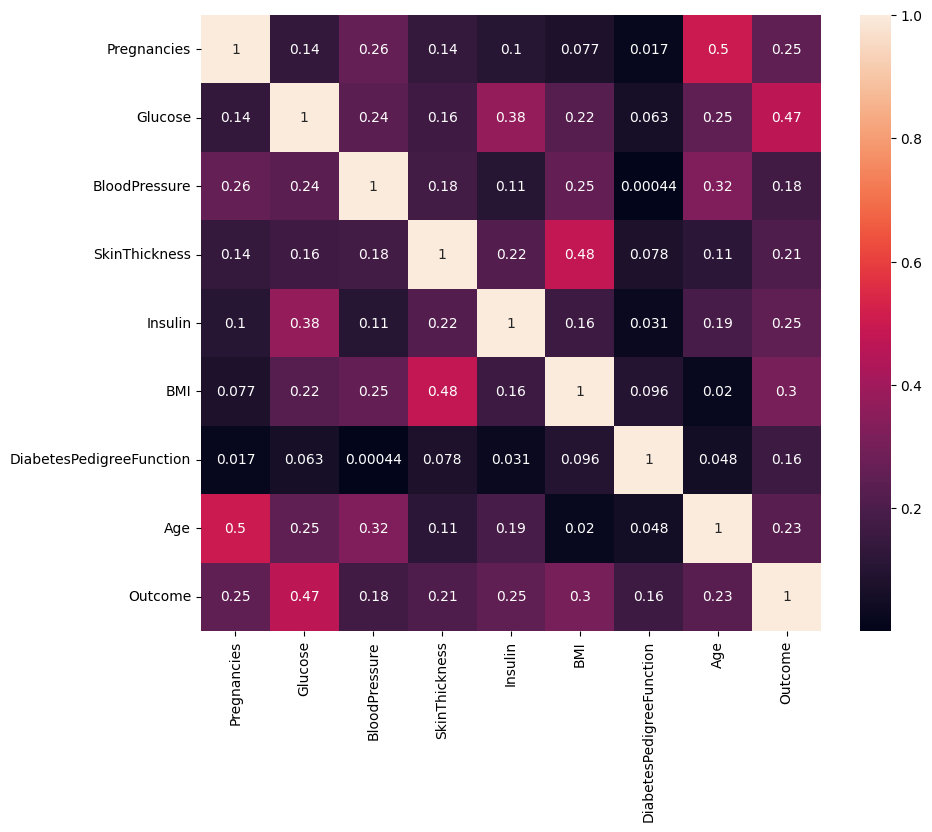

In [158]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)



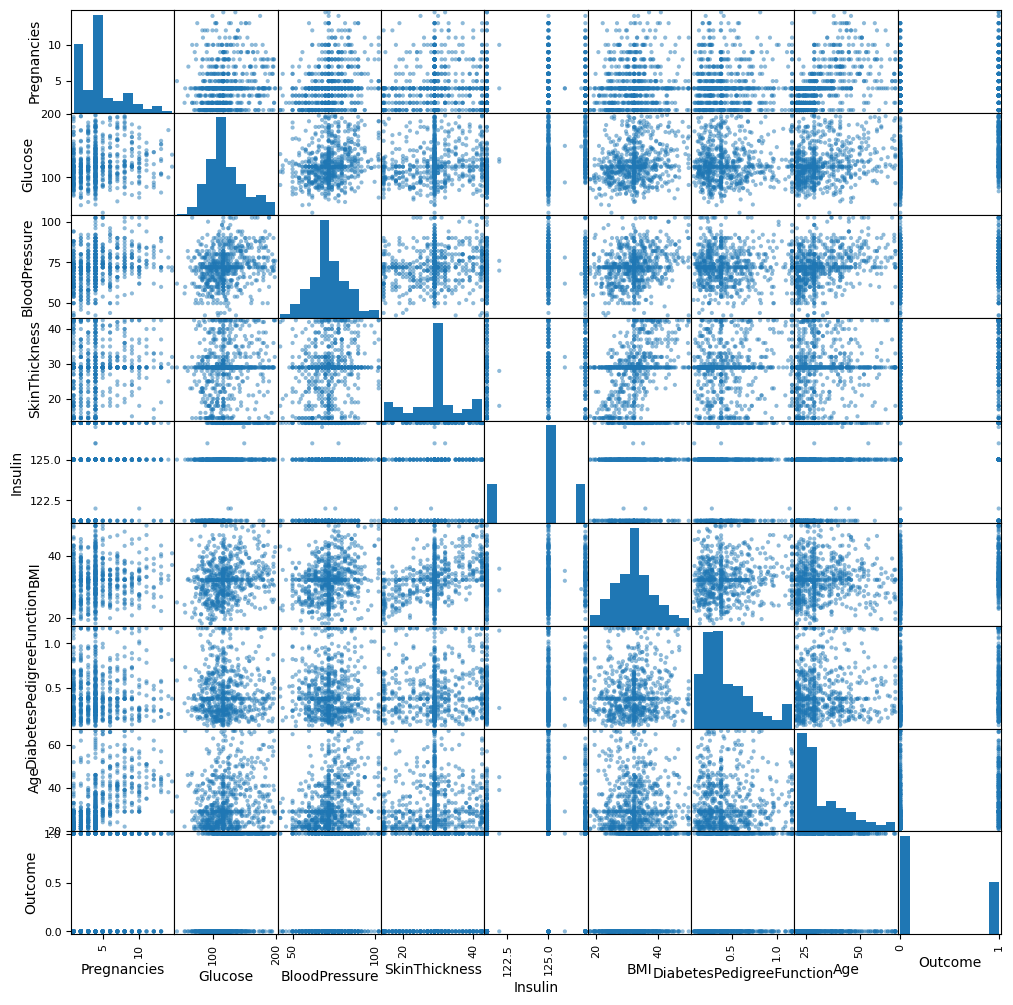

In [159]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(12,12))
plt.show()

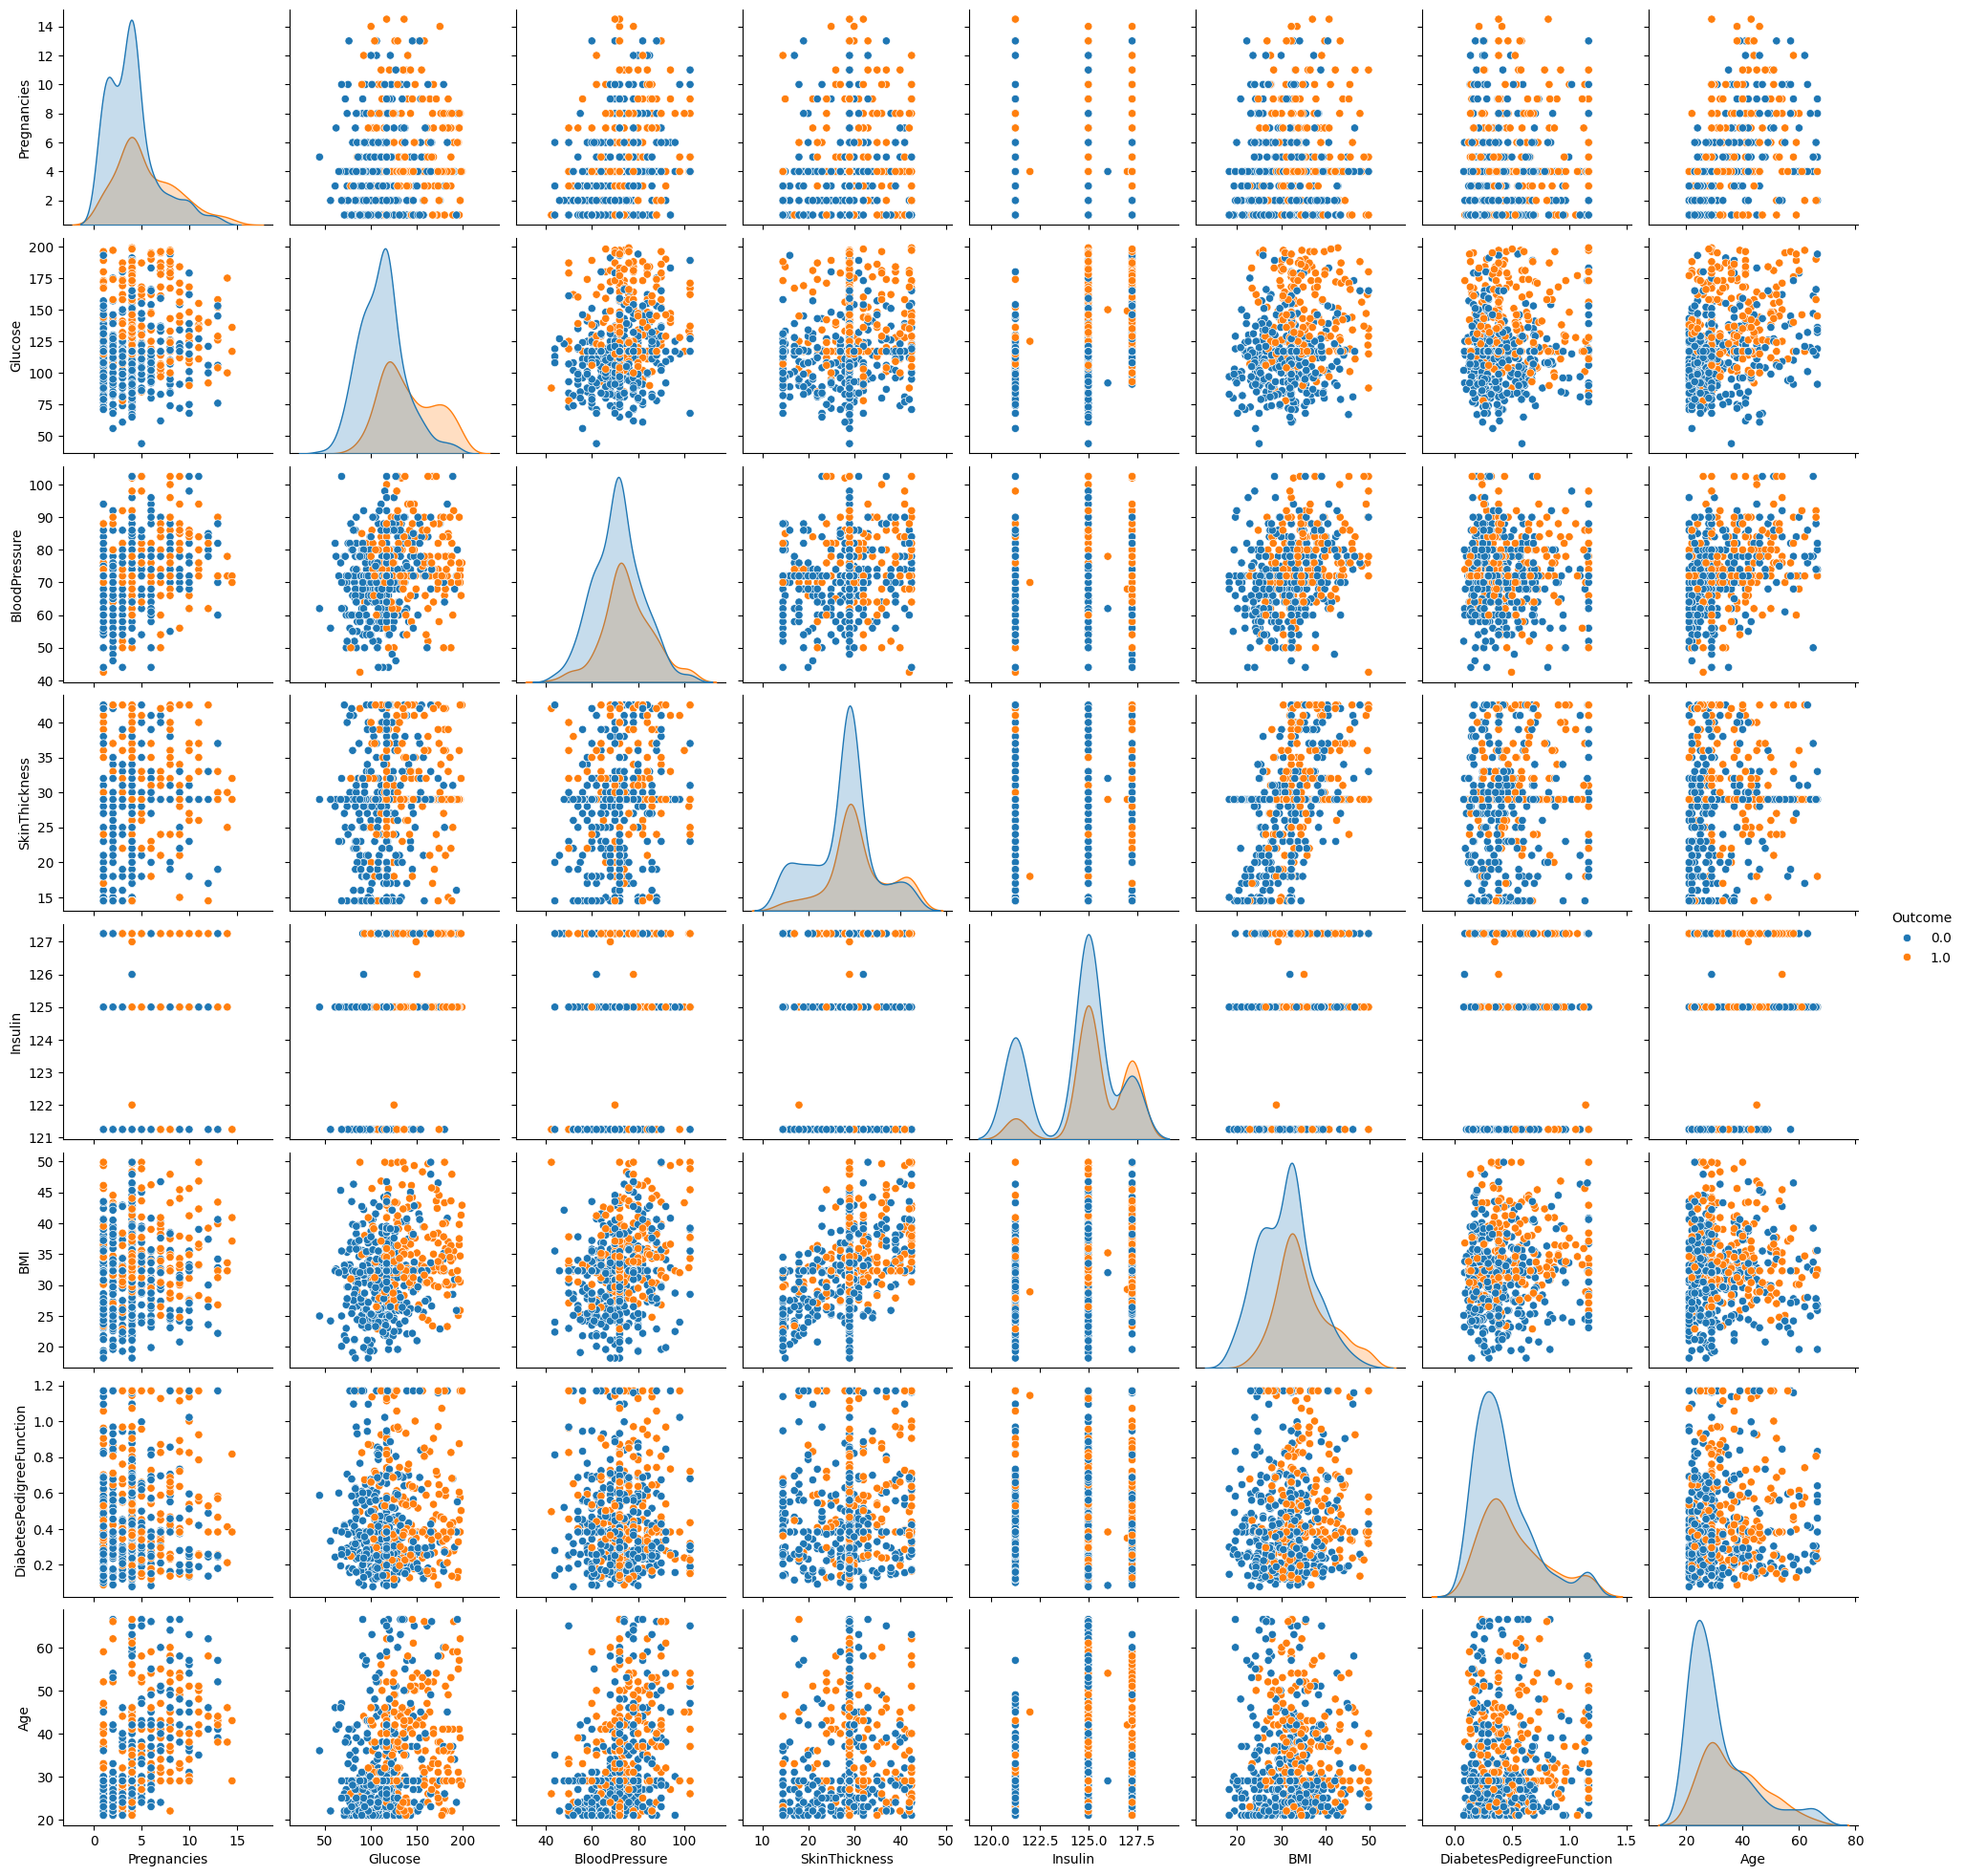

In [117]:
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']


sns.pairplot(df[num_cols + ['Outcome']].sample(600), hue='Outcome')


plt.show()

In [160]:
df['Outcome'].unique()

array([1., 0.])

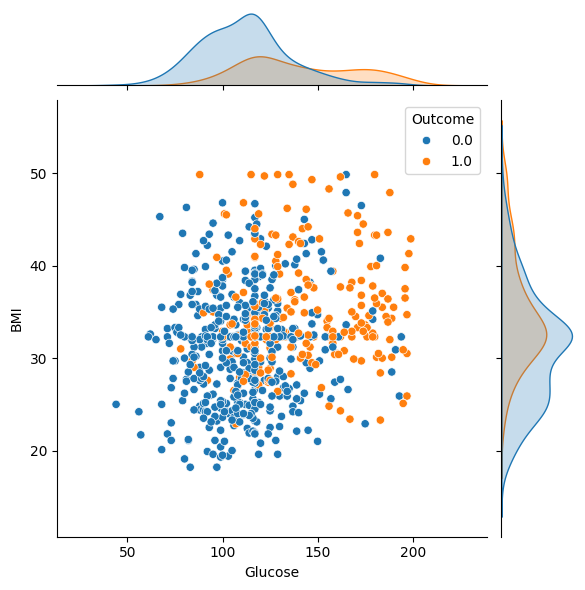

In [161]:
sns.jointplot(data=df, x='Glucose', y='BMI', hue='Outcome')
plt.show()

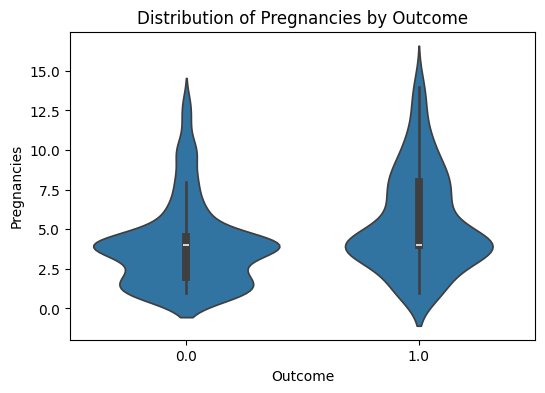

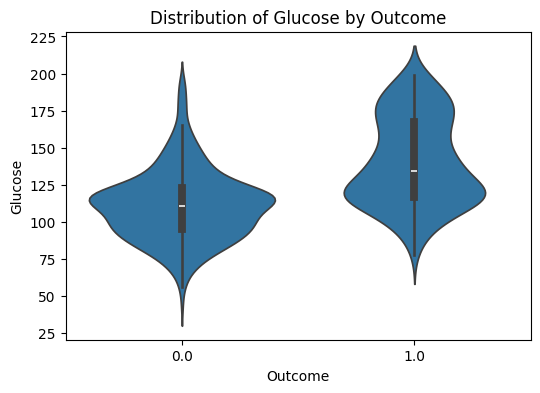

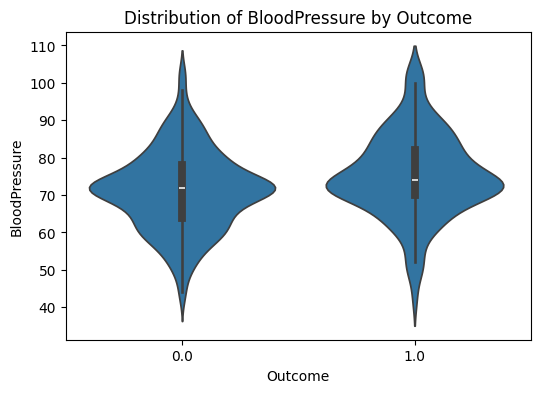

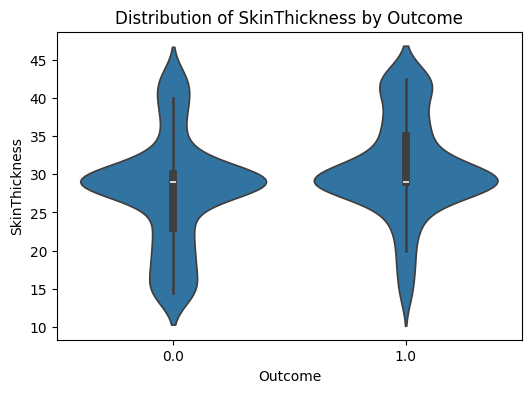

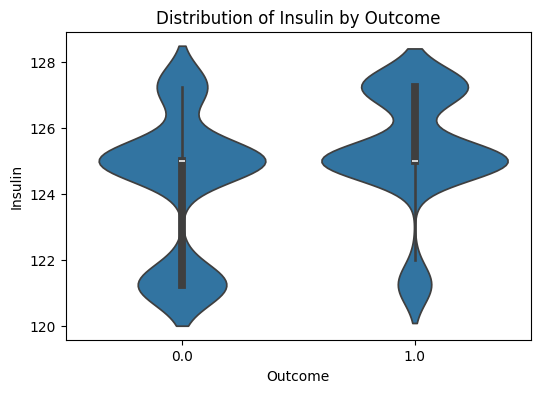

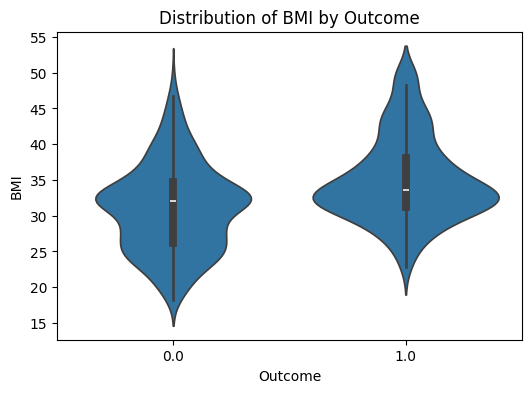

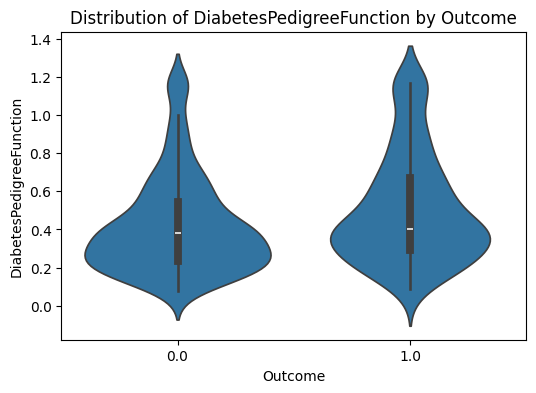

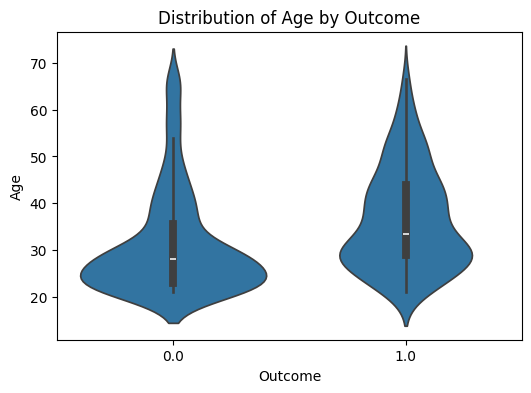

In [162]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(data=df, x='Outcome', y=col)
    plt.title(f'Distribution of {col} by Outcome')
    plt.show()

In [163]:
# bmi_map     = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
# age_map     = {'Young': 0, 'Adult': 1, 'Mid': 2, 'Pre-Senior': 3, 'Senior': 4}
# gluc_map    = {'Normal': 0, 'Prediabetes': 1, 'Diabetes': 2}

# df['BMI_Category_enc']  = df['BMI_Category'].map(bmi_map)
# df['Age_Group_enc']     = df['Age_Group'].map(age_map)
# df['Glucose_Level_enc'] = df['Glucose_Level'].map(gluc_map)

In [164]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
BMI_Category,0


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               691 non-null    float64
 1   Glucose                   691 non-null    float64
 2   BloodPressure             691 non-null    float64
 3   SkinThickness             691 non-null    float64
 4   Insulin                   691 non-null    float64
 5   BMI                       691 non-null    float64
 6   DiabetesPedigreeFunction  691 non-null    float64
 7   Age                       691 non-null    float64
 8   Outcome                   691 non-null    float64
 9   BMI_Category              691 non-null    object 
 10  Age_Group                 691 non-null    object 
 11  Glucose_Level             691 non-null    object 
dtypes: float64(9), object(3)
memory usage: 70.2+ KB


In [166]:

drop_cols = ['BMI_Category', 'Age_Group', 'Glucose_Level'] # insulin because its corrupt or smthing
df_model = df.drop(columns=drop_cols)

X = df_model.drop(columns=['Outcome'])
y = df_model['Outcome']

print("X shape:", X.shape)
print(y.value_counts())

X shape: (691, 8)
Outcome
0.0    451
1.0    240
Name: count, dtype: int64


In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (552, 8)  Test: (139, 8)


In [168]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best accuracy:", round(grid.best_score_, 3))

Best params: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Best accuracy: 0.781


In [169]:
y_pred = grid.best_estimator_.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

Accuracy: 0.784


In [170]:
import pickle
pickle.dump(grid.best_estimator_, open('rf_model.pkl', 'wb'))

In [171]:
X.columns.to_list()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']